In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data_core_daily_v1.csv")

df["data"] = pd.to_datetime(df["data"])
df = df.sort_values(["CFGCENTROID", "data"])

print("Centros:", df["CFGCENTROID"].nunique())
print("Intervalo:", df["data"].min(), "→", df["data"].max())
print("Zeros atuais:", (df["y_inspecoes"] == 0).mean())

Centros: 51
Intervalo: 2022-01-03 00:00:00 → 2025-12-31 00:00:00
Zeros atuais: 0.0


In [3]:
def easter_sunday(year: int) -> pd.Timestamp:
    a = year % 19
    b = year // 100
    c = year % 100
    d = b // 4
    e = b % 4
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    h = (19*a + b - d - g + 15) % 30
    i = c // 4
    k = c % 4
    l = (32 + 2*e + 2*i - h - k) % 7
    m = (a + 11*h + 22*l) // 451
    month = (h + l - 7*m + 114) // 31
    day = ((h + l - 7*m + 114) % 31) + 1
    return pd.Timestamp(year=year, month=month, day=day)

def pt_national_holidays(year):
    fixed = [
        (1,1),(4,25),(5,1),(6,10),
        (8,15),(10,5),(11,1),
        (12,1),(12,8),(12,25)
    ]
    easter = easter_sunday(year)
    movable = [
        easter - pd.Timedelta(days=2),
        easter + pd.Timedelta(days=60)
    ]
    out = {pd.Timestamp(year=year, month=m, day=d) for (m,d) in fixed}
    out |= set(movable)
    return out

years = df["data"].dt.year.unique()
holidays = set()
for y in years:
    holidays |= pt_national_holidays(int(y))

holidays = pd.DatetimeIndex(sorted(holidays))

In [4]:
centers = df["CFGCENTROID"].unique()
start, end = df["data"].min(), df["data"].max()

all_days = pd.date_range(start, end, freq="D")
all_days = all_days[all_days.dayofweek <= 5]

calendar = (
    pd.MultiIndex.from_product([centers, all_days],
                               names=["CFGCENTROID", "data"])
      .to_frame(index=False)
)

base = calendar.merge(
    df[["CFGCENTROID", "data", "y_inspecoes"]],
    on=["CFGCENTROID", "data"],
    how="left"
)

base["is_holiday"] = base["data"].isin(holidays).astype(int)
base["y_inspecoes"] = base["y_inspecoes"].fillna(0)

print("Zeros após reconstrução:", (base["y_inspecoes"] == 0).mean())

Zeros após reconstrução: 0.034450870676008216


In [5]:
base["dow"] = base["data"].dt.dayofweek
base["is_saturday"] = (base["dow"] == 5).astype(int)
base["week"] = base["data"].dt.isocalendar().week.astype(int)
base["month"] = base["data"].dt.month
base["year"] = base["data"].dt.year

In [6]:
base = base.sort_values(["CFGCENTROID", "data"])

for lag in [1, 7, 14, 28]:
    base[f"lag_{lag}"] = (
        base.groupby("CFGCENTROID")["y_inspecoes"]
        .shift(lag)
    )

base["roll7_mean"] = (
    base.groupby("CFGCENTROID")["y_inspecoes"]
    .shift(1)
    .rolling(7)
    .mean()
    .reset_index(level=0, drop=True)
)

base["roll28_mean"] = (
    base.groupby("CFGCENTROID")["y_inspecoes"]
    .shift(1)
    .rolling(28)
    .mean()
    .reset_index(level=0, drop=True)
)

df_model = base.dropna().copy()

In [7]:
cutoff = df_model["data"].max() - pd.DateOffset(months=3)

train = df_model[df_model["data"] <= cutoff]
test  = df_model[df_model["data"] > cutoff]

print("Train:", train.shape)
print("Test:", test.shape)

Train: (58344, 15)
Test: (4029, 15)


In [8]:
features = [
    "CFGCENTROID",
    "dow", "is_saturday", "week", "month", "year",
    "is_holiday",
    "lag_1", "lag_7", "lag_14", "lag_28",
    "roll7_mean", "roll28_mean"
]

X_train = train[features]
y_train = train["y_inspecoes"]

X_test = test[features]
y_test = test["y_inspecoes"]

model = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=400,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)
pred = np.clip(pred, 0, None)

# Forçar 0 em feriados
pred[test["is_holiday"] == 1] = 0

In [9]:
mae = np.mean(np.abs(y_test - pred))
wape_global = np.sum(np.abs(y_test - pred)) / np.sum(y_test)

print("MAE:", round(mae,3))
print("WAPE Global:", round(wape_global,4))

MAE: 12.897
WAPE Global: 0.1188


count    51.000000
mean      0.122677
std       0.020995
min       0.077360
25%       0.108906
50%       0.122265
75%       0.134425
max       0.183368
Name: WAPE, dtype: float64


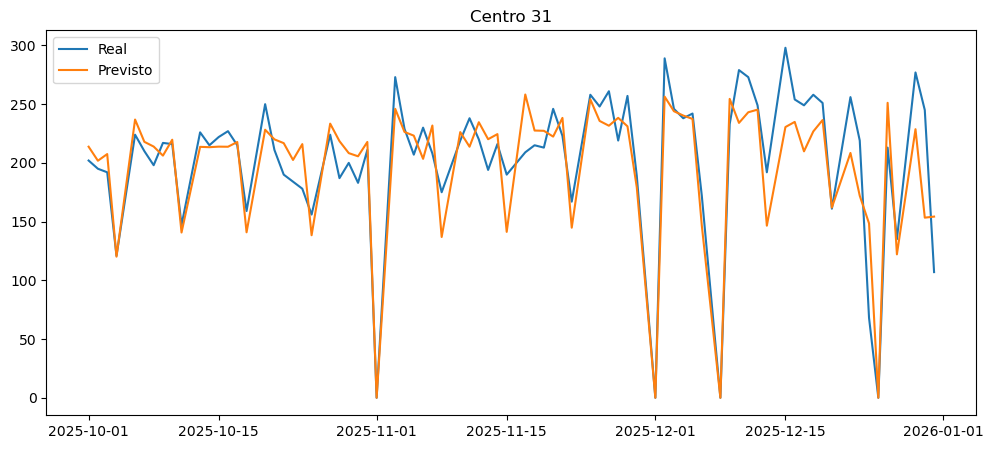

In [10]:
test_result = test.copy()
test_result["pred"] = pred
test_result["abs_err"] = np.abs(test_result["y_inspecoes"] - test_result["pred"])

wape_center = (
    test_result.groupby("CFGCENTROID")
    .agg(
        total_y=("y_inspecoes","sum"),
        total_err=("abs_err","sum")
    )
)

wape_center["WAPE"] = wape_center["total_err"] / wape_center["total_y"]

print(wape_center["WAPE"].describe())

center_big = (
    train.groupby("CFGCENTROID")["y_inspecoes"]
    .mean()
    .sort_values(ascending=False)
    .index[0]
)

plot_df = test_result[test_result["CFGCENTROID"] == center_big]

plt.figure(figsize=(12,5))
plt.plot(plot_df["data"], plot_df["y_inspecoes"], label="Real")
plt.plot(plot_df["data"], plot_df["pred"], label="Previsto")
plt.title(f"Centro {center_big}")
plt.legend()
plt.show()

In [11]:
wape_center.sort_values("WAPE", ascending=False).head(10)

,total_y,total_err,WAPE
CFGCENTROID,,,
187,4639.0,850.645340,0.183368
188,4841.0,801.347101,0.165533
90,5109.0,837.529581,0.163932
57,6932.0,1123.058740,0.162011
4,4249.0,655.062593,0.154169
157,5914.0,868.059280,0.146780
32,5712.0,802.741456,0.140536
239,6364.0,894.178040,0.140506
176,6545.0,907.028112,0.138583


In [12]:
#PARTE 1 — Backtest Rolling (3 janelas móveis de 3 meses):

def train_evaluate(train_df, test_df, features):

    from sklearn.ensemble import HistGradientBoostingRegressor
    import numpy as np

    X_train = train_df[features]
    y_train = train_df["y_inspecoes"]

    X_test = test_df[features]
    y_test = test_df["y_inspecoes"]

    model = HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.05,
        max_iter=400,
        random_state=42
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    pred = np.clip(pred, 0, None)

    # Forçar zero em feriados
    pred[test_df["is_holiday"] == 1] = 0

    mae = np.mean(np.abs(y_test - pred))
    wape = np.sum(np.abs(y_test - pred)) / np.sum(y_test)

    return mae, wape, pred

In [13]:
results = []

max_date = df_model["data"].max()

for i in range(3):

    test_end = max_date - pd.DateOffset(months=i)
    test_start = test_end - pd.DateOffset(months=3)

    train = df_model[df_model["data"] <= test_start]
    test  = df_model[(df_model["data"] > test_start) &
                     (df_model["data"] <= test_end)]

    mae, wape, pred = train_evaluate(train, test, features)

    results.append({
        "split": i+1,
        "test_start": test_start.date(),
        "test_end": test_end.date(),
        "MAE": mae,
        "WAPE": wape
    })

rolling_results = pd.DataFrame(results)
rolling_results

,split,test_start,test_end,MAE,WAPE
0,1,2025-09-30,2025-12-31,12.896549,0.118774
1,2,2025-08-30,2025-11-30,9.876659,0.094889
2,3,2025-07-31,2025-10-31,9.011254,0.094664


In [14]:
rolling_results.describe()

,split,MAE,WAPE
count,3.0,3.000000,3.000000
mean,2.0,10.594821,0.102776
std,1.0,2.039779,0.013855
min,1.0,9.011254,0.094664
25%,1.5,9.443956,0.094777
50%,2.0,9.876659,0.094889
75%,2.5,11.386604,0.106832
max,3.0,12.896549,0.118774


In [15]:
# PARTE 2 — Segmentação por Volume de Centro:
center_volume = (
    df_model.groupby("CFGCENTROID")["y_inspecoes"]
    .mean()
    .reset_index()
    .rename(columns={"y_inspecoes": "mean_daily_volume"})
)

center_volume.head()


,CFGCENTROID,mean_daily_volume
0,4,51.270646
1,9,109.603434
2,10,93.048242
3,12,146.076043
4,13,102.457073


In [16]:
center_volume = (
    df_model.groupby("CFGCENTROID")["y_inspecoes"]
    .mean()
    .rename("mean_daily_volume")
    .reset_index()
)

q1, q2 = center_volume["mean_daily_volume"].quantile([0.33, 0.66]).values

center_volume["segmento"] = pd.cut(
    center_volume["mean_daily_volume"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["Baixo Volume", "Volume Intermédio", "Alto Volume"]
)

center_volume["segmento"].value_counts()

segmento
Baixo Volume         17
Volume Intermédio    17
Alto Volume          17
Name: count, dtype: int64

In [17]:
# Recriar último split
test_end = df_model["data"].max()
test_start = test_end - pd.DateOffset(months=3)

train = df_model[df_model["data"] <= test_start]
test  = df_model[(df_model["data"] > test_start)]

mae, wape, pred = train_evaluate(train, test, features)

test_result = test.copy()
test_result["pred"] = pred
test_result["abs_err"] = np.abs(test_result["y_inspecoes"] - test_result["pred"])

# Juntar segmento
test_result = test_result.merge(center_volume[["CFGCENTROID","segmento"]],
                                on="CFGCENTROID",
                                how="left")

segment_wape = (
    test_result.groupby("segmento")
    .agg(
        total_y=("y_inspecoes","sum"),
        total_err=("abs_err","sum")
    )
)

segment_wape["WAPE"] = segment_wape["total_err"] / segment_wape["total_y"]

segment_wape

/tmp/ipykernel_1751/652382142.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_result.groupby("segmento")


,total_y,total_err,WAPE
segmento,,,
Baixo Volume,102848.0,14285.569777,0.138900
Volume Intermédio,141970.0,16608.790767,0.116988
Alto Volume,192653.0,21065.835499,0.109346


In [18]:
#Comparação ridge, possion e hgo:
from sklearn.linear_model import Ridge, PoissonRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np

def train_model(model_name, X_train, y_train):

    if model_name == "ridge":
        model = Ridge(alpha=1.0)

    elif model_name == "hgb":
        model = HistGradientBoostingRegressor(
            max_depth=6,
            learning_rate=0.05,
            max_iter=400,
            random_state=42
        )

    elif model_name == "poisson":
        model = PoissonRegressor(alpha=0.0, max_iter=1000)

    else:
        raise ValueError("Modelo desconhecido")

    model.fit(X_train, y_train)
    return model

In [19]:
models = ["ridge", "hgb", "poisson"]

comparison_results = []

max_date = df_model["data"].max()

for model_name in models:

    for i in range(3):

        test_end = max_date - pd.DateOffset(months=i)
        test_start = test_end - pd.DateOffset(months=3)

        train = df_model[df_model["data"] <= test_start]
        test  = df_model[(df_model["data"] > test_start) &
                         (df_model["data"] <= test_end)]

        X_train = train[features]
        y_train = train["y_inspecoes"]
        X_test  = test[features]
        y_test  = test["y_inspecoes"]

        model = train_model(model_name, X_train, y_train)

        pred = model.predict(X_test)
        pred = np.clip(pred, 0, None)
        pred[test["is_holiday"] == 1] = 0

        mae = np.mean(np.abs(y_test - pred))
        wape = np.sum(np.abs(y_test - pred)) / np.sum(y_test)

        comparison_results.append({
            "model": model_name,
            "split": i+1,
            "MAE": mae,
            "WAPE": wape
        })

comparison_df = pd.DataFrame(comparison_results)
comparison_df

/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights


,model,split,MAE,WAPE
0,ridge,1,15.752312,0.145075
1,ridge,2,11.824699,0.113605
2,ridge,3,12.131824,0.127446
3,hgb,1,12.896549,0.118774
4,hgb,2,9.876659,0.094889
5,hgb,3,9.011254,0.094664
6,poisson,1,33.520877,0.308719
7,poisson,2,30.952493,0.297373
8,poisson,3,30.704494,0.322554


In [20]:
comparison_df.groupby("model")[["MAE", "WAPE"]].mean().sort_values("WAPE")

,MAE,WAPE
model,,
hgb,10.594821,0.102776
ridge,13.236278,0.128708
poisson,31.725955,0.309549


In [21]:
# Baseline Mean by Day of Week:
def mean_by_dow_baseline(train, test):

    # média por centro e dia da semana
    mean_table = (
        train.groupby(["CFGCENTROID", "dow"])["y_inspecoes"]
        .mean()
        .reset_index()
        .rename(columns={"y_inspecoes": "mean_dow"})
    )

    test_baseline = test.merge(mean_table,
                               on=["CFGCENTROID", "dow"],
                               how="left")

    pred = test_baseline["mean_dow"].values
    pred[test_baseline["is_holiday"] == 1] = 0

    mae = np.mean(np.abs(test["y_inspecoes"] - pred))
    wape = np.sum(np.abs(test["y_inspecoes"] - pred)) / np.sum(test["y_inspecoes"])

    return mae, wape

In [22]:
# split final
test_end = df_model["data"].max()
test_start = test_end - pd.DateOffset(months=3)

train = df_model[df_model["data"] <= test_start]
test  = df_model[df_model["data"] > test_start]

# HGB
mae_hgb, wape_hgb, pred_hgb = train_evaluate(train, test, features)

# Baseline
mae_base, wape_base = mean_by_dow_baseline(train, test)

print("Baseline MAE:", round(mae_base,2))
print("Baseline WAPE:", round(wape_base,4))
print("HGB MAE:", round(mae_hgb,2))
print("HGB WAPE:", round(wape_hgb,4))

Baseline MAE: 17.12
Baseline WAPE: 0.1576
HGB MAE: 12.9
HGB WAPE: 0.1188


In [23]:
# Split final (últimos 3 meses)
test_end = df_model["data"].max()
test_start = test_end - pd.DateOffset(months=3)

train = df_model[df_model["data"] <= test_start]
test  = df_model[df_model["data"] > test_start]

X_train = train[features]
y_train = train["y_inspecoes"]

X_test = test[features]
y_test = test["y_inspecoes"]

from sklearn.ensemble import HistGradientBoostingRegressor

model_hgb = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=400,
    random_state=42
)

model_hgb.fit(X_train, y_train)

,loss,'squared_error'
,quantile,None
,learning_rate,0.05
,max_iter,400
,max_leaf_nodes,31
,max_depth,6
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'


In [24]:
#Gráfico Real vs Previsto + Diferença:
center_median = (
    center_volume.sort_values("mean_daily_volume")
    .iloc[len(center_volume)//2]["CFGCENTROID"]
)

center_median

178

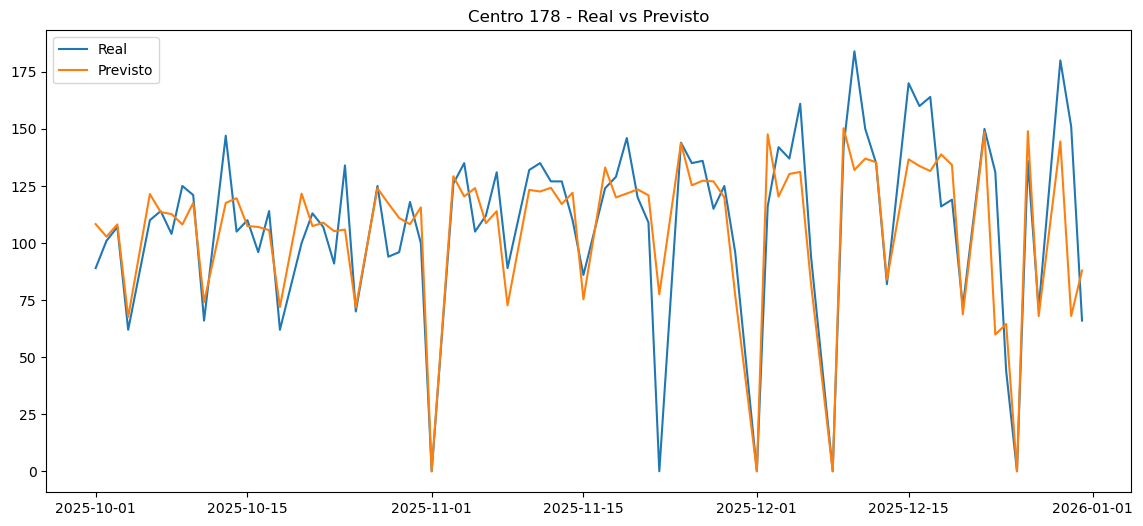

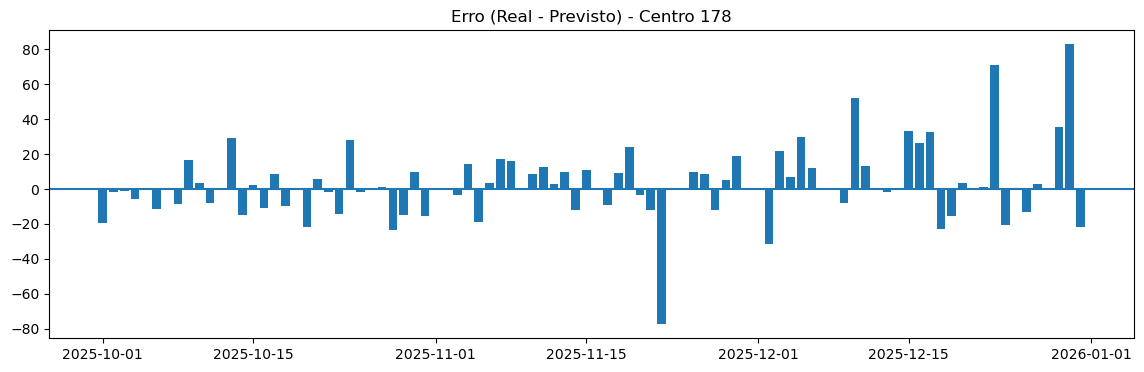

In [25]:
plot_df = test.copy()
plot_df["pred"] = pred_hgb
plot_df = plot_df[plot_df["CFGCENTROID"] == center_median]

plot_df["erro"] = plot_df["y_inspecoes"] - plot_df["pred"]

plt.figure(figsize=(14,6))
plt.plot(plot_df["data"], plot_df["y_inspecoes"], label="Real")
plt.plot(plot_df["data"], plot_df["pred"], label="Previsto")
plt.title(f"Centro {center_median} - Real vs Previsto")
plt.legend()
plt.show()

plt.figure(figsize=(14,4))
plt.bar(plot_df["data"], plot_df["erro"])
plt.title(f"Erro (Real - Previsto) - Centro {center_median}")
plt.axhline(0)
plt.show()

In [26]:
base = base.sort_values(["CFGCENTROID", "data"])

# índice temporal contínuo
base["time_idx"] = (base["data"] - base["data"].min()).dt.days

# novos lags
for lag in [2, 3]:
    base[f"lag_{lag}"] = (
        base.groupby("CFGCENTROID")["y_inspecoes"]
        .shift(lag)
    )

# rolling mediana
base["roll7_median"] = (
    base.groupby("CFGCENTROID")["y_inspecoes"]
    .shift(1)
    .rolling(7)
    .median()
    .reset_index(level=0, drop=True)
)

df_model = base.dropna().copy()

In [27]:
features_refined = [
    "CFGCENTROID",
    "dow",
    "month",
    "is_saturday",
    "is_holiday",
    "time_idx",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "roll7_mean",
    "roll28_mean"
]

In [28]:
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor

# Garantir que time_idx existe
df_model = df_model.copy()
df_model["time_idx"] = (df_model["data"] - df_model["data"].min()).dt.days

features_refined = [
    "CFGCENTROID",
    "dow",
    "month",
    "is_saturday",
    "is_holiday",
    "time_idx",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "roll7_mean",
    "roll28_mean",
]

# Split final: últimos 3 meses
test_end = df_model["data"].max()
test_start = test_end - pd.DateOffset(months=3)

train = df_model[df_model["data"] <= test_start]
test  = df_model[df_model["data"] > test_start]

X_train = train[features_refined]
y_train = train["y_inspecoes"]

X_test = test[features_refined]
y_test = test["y_inspecoes"]

model_refined = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=400,
    random_state=42
)

# FIT (faltava isto)
model_refined.fit(X_train, y_train)

pred_refined = model_refined.predict(X_test)
pred_refined = np.clip(pred_refined, 0, None)
pred_refined[test["is_holiday"] == 1] = 0

mae_refined = np.mean(np.abs(y_test - pred_refined))
wape_refined = np.sum(np.abs(y_test - pred_refined)) / np.sum(y_test)

print("MAE refined:", round(mae_refined, 3))
print("WAPE refined:", round(wape_refined, 4))

MAE refined: 16.121
WAPE refined: 0.1485


In [29]:
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np
import itertools

param_grid = {
    "max_depth": [5,6,7],
    "learning_rate": [0.03, 0.05],
    "max_iter": [300,400,500]
}

results_grid = []

for md, lr, mi in itertools.product(
    param_grid["max_depth"],
    param_grid["learning_rate"],
    param_grid["max_iter"]):
    
    model = HistGradientBoostingRegressor(
        max_depth=md,
        learning_rate=lr,
        max_iter=mi,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    pred = np.clip(pred, 0, None)
    pred[test["is_holiday"] == 1] = 0
    
    wape = np.sum(np.abs(y_test - pred)) / np.sum(y_test)
    
    results_grid.append({
        "max_depth": md,
        "learning_rate": lr,
        "max_iter": mi,
        "WAPE": wape
    })

grid_df = pd.DataFrame(results_grid).sort_values("WAPE")
grid_df.head(10)

,max_depth,learning_rate,max_iter,WAPE
0,5,0.03,300,0.121705
1,5,0.03,400,0.124839
2,5,0.03,500,0.127988
12,7,0.03,300,0.128913
13,7,0.03,400,0.131297
6,6,0.03,300,0.133976
7,6,0.03,400,0.134272
14,7,0.03,500,0.135860
3,5,0.05,300,0.136321
4,5,0.05,400,0.136824


In [30]:
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np

def train_per_center(df_model, features):

    test_end = df_model["data"].max()
    test_start = test_end - pd.DateOffset(months=3)

    train_all = df_model[df_model["data"] <= test_start]
    test_all  = df_model[df_model["data"] > test_start]

    results = []

    for center in df_model["CFGCENTROID"].unique():

        train = train_all[train_all["CFGCENTROID"] == center]
        test  = test_all[test_all["CFGCENTROID"] == center]

        if len(test) == 0 or len(train) < 200:
            continue

        X_train = train[features]
        y_train = train["y_inspecoes"]

        X_test = test[features]
        y_test = test["y_inspecoes"]

        model = HistGradientBoostingRegressor(
            max_depth=6,
            learning_rate=0.05,
            max_iter=400,
            random_state=42
        )

        model.fit(X_train, y_train)

        pred = model.predict(X_test)
        pred = np.clip(pred, 0, None)
        pred[test["is_holiday"] == 1] = 0

        total_y = np.sum(y_test)
        total_err = np.sum(np.abs(y_test - pred))

        results.append({
            "CFGCENTROID": center,
            "total_y": total_y,
            "total_err": total_err,
            "WAPE": total_err / total_y
        })

    results_df = pd.DataFrame(results)

    wape_global = results_df["total_err"].sum() / results_df["total_y"].sum()

    return results_df, wape_global

In [31]:
results_center, wape_center_model = train_per_center(df_model, features)

print("WAPE modelo por centro:", round(wape_center_model,4))
results_center["WAPE"].describe()

WAPE modelo por centro: 0.1211


count    51.000000
mean      0.125489
std       0.021415
min       0.080940
25%       0.112880
50%       0.124542
75%       0.134456
max       0.177581
Name: WAPE, dtype: float64

In [32]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor

# carregar dados
df = pd.read_csv("data_core_daily_v1.csv")
df["data"] = pd.to_datetime(df["data"])
df = df.sort_values(["CFGCENTROID","data"])

# usar diretamente (sem reconstrução adicional)
df_model = df.copy()

# features do modelo diário original
features_daily = [
    "CFGCENTROID",
    "dow",
    "week",
    "month",
    "is_saturday",
    "is_holiday",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "roll7_mean",
    "roll28_mean"
]

In [33]:
# criar dataframe com previsões diárias
daily_test = test.copy()
daily_test["pred"] = pred_hgb

# criar semana ISO
daily_test["year"] = daily_test["data"].dt.isocalendar().year
daily_test["week"] = daily_test["data"].dt.isocalendar().week

weekly_from_daily = (
    daily_test
    .groupby(["CFGCENTROID","year","week"])
    .agg(
        real=("y_inspecoes","sum"),
        pred=("pred","sum")
    )
    .reset_index()
)

weekly_from_daily["abs_err"] = abs(weekly_from_daily["real"] - weekly_from_daily["pred"])

wape_weekly_from_daily = (
    weekly_from_daily["abs_err"].sum() /
    weekly_from_daily["real"].sum()
)

print("WAPE semanal (agregado do modelo diário):", round(wape_weekly_from_daily,4))

WAPE semanal (agregado do modelo diário): 0.0594


In [34]:
import pandas as pd
import numpy as np

# Escolher previsões automaticamente
# Preferência (diário): refined -> hgb -> pred (genérico) -> pred_daily -> pred_ensemble
_pred_candidates = ["pred_refined", "pred_hgb", "pred", "pred_daily", "pred_ensemble"]
pred_vec = None
pred_name = None

for name in _pred_candidates:
    if name in globals():
        pred_vec = globals()[name]
        pred_name = name
        break

if pred_vec is None:
    raise ValueError("Não encontrei nenhum vetor de previsões (ex.: pred_refined, pred_hgb, pred, pred_daily).")

# Garantir que existe 'test'
if "test" not in globals():
    raise ValueError("Não encontrei o DataFrame 'test' no notebook diário.")

df_out = test.copy()
df_out["data"] = pd.to_datetime(df_out["data"])
df_out["y_pred"] = np.asarray(pred_vec)

# Filtrar últimas 4 semanas

max_date = df_out["data"].max()
cutoff = max_date - pd.DateOffset(weeks=4)
df_out = df_out[df_out["data"] >= cutoff].copy()

# Erros linha a linha
df_out["err"] = df_out["y_inspecoes"] - df_out["y_pred"]
df_out["abs_err"] = df_out["err"].abs()
df_out["sq_err"] = df_out["err"] ** 2

# Métricas POR DIA (agregado sobre centros)
daily_metrics = (
    df_out
    .groupby(["data"], as_index=False)
    .agg(
        real_total=("y_inspecoes", "sum"),
        pred_total=("y_pred", "sum"),
        MAE=("abs_err", "mean"),
        RMSE=("sq_err", lambda x: float(np.sqrt(np.mean(x)))),
        WAPE=("abs_err", "sum"),
        n_centers=("CFGCENTROID", "nunique")
    )
)

daily_metrics["WAPE"] = daily_metrics["WAPE"] / daily_metrics["real_total"].replace(0, np.nan)
daily_metrics["model_pred_used"] = pred_name

# Juntar métricas diárias ao detalhe (fica “1 parquet só”, mas com as métricas do dia repetidas)
daily_out = df_out.merge(daily_metrics, on="data", how="left")

# Guardar
out_path = "output_diario_4semanas.parquet"
daily_out.to_parquet(out_path, index=False)

print("OK", out_path)
print("Predições usadas:", pred_name)
print("Dias:", daily_out["data"].min().date(), "→", daily_out["data"].max().date())
print("Linhas (centro-dia):", daily_out.shape[0])

OK output_diario_4semanas.parquet
Predições usadas: pred_refined
Dias: 2025-12-03 → 2025-12-31
Linhas (centro-dia): 1275


In [35]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor

# Helpers

def pick_existing_features(df_model):
    # tenta encontrar uma lista de features já definida no notebook
    candidates = ["features_final", "features_daily", "features", "FEATURES"]
    for name in candidates:
        if name in globals() and isinstance(globals()[name], (list, tuple)):
            feats = list(globals()[name])
            # mantém só as que existem
            feats = [f for f in feats if f in df_model.columns]
            if len(feats) > 0:
                return feats, name
    # fallback: usar tudo menos target/data
    drop = {"y_inspecoes", "y", "data", "DATE"}
    feats = [c for c in df_model.columns if c not in drop]
    return feats, "auto"

def ensure_time_cols(df):
    df = df.copy()
    df["data"] = pd.to_datetime(df["data"])
    if "dow" not in df.columns:
        df["dow"] = df["data"].dt.dayofweek
    if "week" not in df.columns:
        df["week"] = df["data"].dt.isocalendar().week.astype(int)
    if "month" not in df.columns:
        df["month"] = df["data"].dt.month.astype(int)
    if "year" not in df.columns:
        df["year"] = df["data"].dt.year.astype(int)
    if "is_saturday" not in df.columns:
        df["is_saturday"] = (df["dow"] == 5).astype(int)
    return df

# Backtest -> MÉTRICAS (últimas 2 semanas, 1 linha por centro)

if "test" not in globals():
    raise ValueError("Não encontrei o DataFrame 'test' no notebook diário.")
if "pred_hgb" in globals():
    pred_past = pred_hgb
elif "pred" in globals():
    pred_past = pred
else:
    raise ValueError("Não encontrei previsões no diário (pred_hgb ou pred).")

bt = test.copy()
bt["DATE"] = pd.to_datetime(bt["data"])
bt["real"] = bt["y_inspecoes"].astype(float)
bt["previsto"] = np.asarray(pred_past, dtype=float)

bt_max = bt["DATE"].max()
bt_cut = bt_max - pd.DateOffset(weeks=2)
bt_win = bt[bt["DATE"] >= bt_cut].copy()

bt_win["err"] = bt_win["real"] - bt_win["previsto"]
bt_win["abs_err"] = bt_win["err"].abs()
bt_win["sq_err"] = bt_win["err"] ** 2

metrics_diario = (
    bt_win.groupby("CFGCENTROID", as_index=False)
    .agg(
        real=("real", "sum"),
        previsto=("previsto", "sum"),
        mae=("abs_err", "mean"),
        rmse=("sq_err", lambda x: float(np.sqrt(np.mean(x)))),
        wape=("abs_err", "sum"),
    )
)
metrics_diario["wape"] = metrics_diario["wape"] / metrics_diario["real"].replace(0, np.nan)
metrics_diario.to_parquet("metrics_diario.parquet", index=False)
print("OK ✅ metrics_diario.parquet")

# HISTORY 
# tenta usar df_model (preferível) para history; senão df
if "df_model" in globals():
    hist_src = df_model.copy()
elif "df" in globals():
    hist_src = df.copy()
else:
    raise ValueError("Não encontrei df_model nem df para construir history.")

hist_src = ensure_time_cols(hist_src)
hist_src["DATE"] = hist_src["data"]
hist_max = hist_src["DATE"].max()
hist_cut = hist_max - pd.DateOffset(weeks=2)

history_long = hist_src[hist_src["DATE"] >= hist_cut][["CFGCENTROID", "DATE", "y_inspecoes"]].copy()
history_long = history_long.rename(columns={"y_inspecoes": "value"})
history_long["kind"] = "history"

# FORECAST (próximas 2 semanas) -> recursivo, features existentes
# garantir df_model existe e tem colunas temporais
if "df_model" not in globals():
    df_model = df.dropna().copy()
df_model = ensure_time_cols(df_model)

features_used, feat_name = pick_existing_features(df_model)

# sanity: precisamos de CFGCENTROID nas features (modelo por centro)
if "CFGCENTROID" not in df_model.columns:
    raise ValueError("df_model não tem CFGCENTROID.")

# modelo final
model_final = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=400,
    random_state=42
)
model_final.fit(df_model[features_used], df_model["y_inspecoes"])

# calendário futuro: 14 dias (exclui domingos)
last_date = df_model["data"].max()
future_days = pd.date_range(last_date + pd.Timedelta(days=1),
                            last_date + pd.Timedelta(days=14),
                            freq="D")
future_days = future_days[future_days.dayofweek <= 5]

centers = df_model["CFGCENTROID"].unique()

rows = []
for d in future_days:
    dow = d.dayofweek
    row_base = {
        "data": d,
        "dow": dow,
        "week": int(d.isocalendar().week),
        "month": int(d.month),
        "year": int(d.year),
        "is_saturday": 1 if dow == 5 else 0,
    }

    for c in centers:
        feat = row_base.copy()
        feat["CFGCENTROID"] = c

        X = pd.DataFrame([feat])
        # criar colunas que o modelo espera, e preencher missing com NaN
        for col in features_used:
            if col not in X.columns:
                X[col] = np.nan
        X = X[features_used]

        yhat = float(model_final.predict(X)[0])
        yhat = max(0.0, yhat)
        rows.append((c, d, yhat))

forecast_long = pd.DataFrame(rows, columns=["CFGCENTROID", "DATE", "value"])
forecast_long["kind"] = "forecast"

# Guardar dados_diario.parquet

dados_diario = (
    pd.concat([history_long, forecast_long], ignore_index=True)
    .sort_values(["CFGCENTROID", "DATE", "kind"])
)
dados_diario = dados_diario[["CFGCENTROID", "DATE", "value", "kind"]]
dados_diario.to_parquet("dados_diario.parquet", index=False)
print("OK dados_diario.parquet")
print("Features usadas no forecast:", feat_name, "|", features_used)

OK ✅ metrics_diario.parquet
OK dados_diario.parquet
Features usadas no forecast: features_daily | ['CFGCENTROID', 'dow', 'week', 'month', 'is_saturday']


In [36]:
import pandas as pd
import numpy as np

# escolher previsões
if "pred_hgb" in globals():
    pred_used = pred_hgb
elif "pred" in globals():
    pred_used = pred
else:
    raise ValueError("Não encontrei vetor de previsões (pred ou pred_hgb).")

# construir base de backtest
bt = test.copy()
bt["DATE"] = pd.to_datetime(bt["data"])
bt["real"] = bt["y_inspecoes"].astype(float)
bt["previsto"] = np.asarray(pred_used, dtype=float)

# últimas 2 semanas
cutoff = bt["DATE"].max() - pd.DateOffset(weeks=2)
bt = bt[bt["DATE"] >= cutoff].copy()

# erros
bt["err"] = bt["real"] - bt["previsto"]
bt["abs_err"] = bt["err"].abs()
bt["sq_err"] = bt["err"] ** 2

# métricas por centro
metrics_diario = (
    bt.groupby("CFGCENTROID", as_index=False)
    .agg(
        real=("real","sum"),
        previsto=("previsto","sum"),
        mae=("abs_err","mean"),
        rmse=("sq_err", lambda x: float(np.sqrt(np.mean(x)))),
        wape=("abs_err","sum")
    )
)


In [37]:
metrics_diario.parquet

Centro 31
WAPE: 20.46 %
MAE: 38.39
RMSE: 46.62

Global
WAPE médio: 22.62 %
WAPE mediano: 22.66 %


In [38]:
print(test.shape)
print(len(pred_hgb) if "pred_hgb" in globals() else len(pred))
metrics_diario["wape"].describe()

(4029, 19)
4029


count    51.000000
mean      0.226159
std       0.037005
min       0.166223
25%       0.201520
50%       0.226610
75%       0.248116
max       0.319791
Name: wape, dtype: float64

In [42]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor

# --- sanity ---
assert "df_model" in globals(), "Preciso de df_model"
assert "features" in globals(), "Preciso da lista features"

dfm = df_model.copy()
dfm["data"] = pd.to_datetime(dfm["data"])

# usar apenas features que existem (evita KeyError)
features_ok = [f for f in features if f in dfm.columns]
print("Features usadas:", features_ok)

# split exatamente como no teu train_per_center (últimos 3 meses)
test_end = dfm["data"].max()
test_start = test_end - pd.DateOffset(months=3)

train_all = dfm[dfm["data"] <= test_start].copy()
test_all  = dfm[dfm["data"] > test_start].copy()

rows = []
pred_rows = []  # para (opcional) gráficos/backtest por dia

for center in dfm["CFGCENTROID"].unique():
    train_c = train_all[train_all["CFGCENTROID"] == center].copy()
    test_c  = test_all[test_all["CFGCENTROID"] == center].copy()

    if len(test_c) == 0 or len(train_c) < 200:
        continue

    X_train = train_c[features_ok]
    y_train = train_c["y_inspecoes"].astype(float)

    X_test = test_c[features_ok]
    y_test = test_c["y_inspecoes"].astype(float)

    model = HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.05,
        max_iter=400,
        random_state=42
    )
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    pred = np.clip(pred, 0, None)

    # regra feriado se existir a coluna no test_c
    if "is_holiday" in test_c.columns:
        pred[test_c["is_holiday"] == 1] = 0

    abs_err = np.abs(y_test.values - pred)
    sq_err  = (y_test.values - pred) ** 2

    real_total = float(np.sum(y_test))
    prev_total = float(np.sum(pred))
    mae = float(np.mean(abs_err))
    rmse = float(np.sqrt(np.mean(sq_err)))
    wape = float(np.sum(abs_err) / real_total) if real_total > 0 else np.nan

    rows.append({
        "CFGCENTROID": int(center),
        "real": real_total,
        "previsto": prev_total,
        "mae": mae,
        "rmse": rmse,
        "wape": wape,
        "n_obs": int(len(test_c)),
        "test_start": test_c["data"].min(),
        "test_end": test_c["data"].max(),
    })

    # (opcional) guardar por dia para gráfico/backtest
    pred_rows.append(pd.DataFrame({
        "CFGCENTROID": int(center),
        "DATE": pd.to_datetime(test_c["data"]).values,
        "real": y_test.values,
        "previsto": pred
    }))

metrics_diario = pd.DataFrame(rows).sort_values("CFGCENTROID").reset_index(drop=True)

# WAPE global ponderado (bom para KPI)
WAPE_global = (metrics_diario["real"] * metrics_diario["wape"]).sum() / metrics_diario["real"].sum()
metrics_diario["WAPE_global"] = WAPE_global

# guardar parquet (se não tiver engine, guarda csv)
try:
    metrics_diario.to_parquet("metrics_diario.parquet", index=False)
    print("OK ✅ metrics_diario.parquet")
except Exception as e:
    metrics_diario.to_csv("metrics_diario.csv", index=False)
    print("Sem engine parquet. Gravei metrics_diario.csv. Erro:", e)

print("WAPE_global (3 meses, modelo por centro):", round(WAPE_global*100,2), "%")
print(metrics_diario["wape"].describe())

Features usadas: ['CFGCENTROID', 'dow', 'is_saturday', 'week', 'month', 'year']
OK ✅ metrics_diario.parquet
WAPE_global (3 meses, modelo por centro): 12.3 %
count    51.000000
mean      0.126038
std       0.018369
min       0.074286
25%       0.115828
50%       0.125634
75%       0.135904
max       0.161621
Name: wape, dtype: float64


In [43]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor

dfm = df_model.copy()
dfm["data"] = pd.to_datetime(dfm["data"])

features_ok = [f for f in features if f in dfm.columns]

# ---------- HISTORY: últimas 2 semanas reais ----------
hist_end = dfm["data"].max()
hist_start = hist_end - pd.DateOffset(weeks=2)

history_long = (
    dfm[dfm["data"] >= hist_start][["CFGCENTROID", "data", "y_inspecoes"]]
    .rename(columns={"data":"DATE", "y_inspecoes":"value"})
    .copy()
)
history_long["kind"] = "history"

# ---------- FORECAST: próximas 2 semanas ----------
future_days = pd.date_range(hist_end + pd.Timedelta(days=1), hist_end + pd.Timedelta(days=14), freq="D")
future_days = future_days[future_days.dayofweek <= 5]  # exclui domingos

# utilitários p/ lags/rolls se existirem
def get_lag(seq, k):
    return seq[-k] if len(seq) >= k else np.nan

def get_roll(seq, k):
    return float(np.mean(seq[-k:])) if len(seq) >= k else np.nan

forecast_rows = []

for center in dfm["CFGCENTROID"].unique():
    df_c = dfm[dfm["CFGCENTROID"] == center].sort_values("data").copy()
    if len(df_c) < 200:
        continue

    # treino em todo o histórico
    X_train = df_c[features_ok]
    y_train = df_c["y_inspecoes"].astype(float)

    model = HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.05,
        max_iter=400,
        random_state=42
    )
    model.fit(X_train, y_train)

    # sequência para lags/rolls (se usados)
    seq = list(y_train.values)

    for d in future_days:
        feat = {"CFGCENTROID": center}

        # temporais se existirem
        if "dow" in features_ok: feat["dow"] = d.dayofweek
        if "week" in features_ok: feat["week"] = int(d.isocalendar().week)
        if "month" in features_ok: feat["month"] = int(d.month)
        if "year" in features_ok: feat["year"] = int(d.year)
        if "is_saturday" in features_ok: feat["is_saturday"] = 1 if d.dayofweek == 5 else 0

        # feriado se existir feature/coluna is_holiday
        if "is_holiday" in features_ok:
            # se tiveres lista `holidays` no notebook, usa-a
            hol_set = set(pd.to_datetime(list(holidays)).normalize()) if "holidays" in globals() else set()
            feat["is_holiday"] = 1 if d.normalize() in hol_set else 0

        # lags/rolls se existirem
        if "lag_1" in features_ok: feat["lag_1"] = get_lag(seq, 1)
        if "lag_7" in features_ok: feat["lag_7"] = get_lag(seq, 7)
        if "lag_14" in features_ok: feat["lag_14"] = get_lag(seq, 14)
        if "lag_28" in features_ok: feat["lag_28"] = get_lag(seq, 28)
        if "roll7_mean" in features_ok: feat["roll7_mean"] = get_roll(seq, 7)
        if "roll28_mean" in features_ok: feat["roll28_mean"] = get_roll(seq, 28)

        X = pd.DataFrame([feat])
        for col in features_ok:
            if col not in X.columns:
                X[col] = np.nan
        X = X[features_ok]

        yhat = float(model.predict(X)[0])
        yhat = max(0.0, yhat)

        # regra: se is_holiday existir e for feriado, força 0
        if "is_holiday" in features_ok and feat.get("is_holiday", 0) == 1:
            yhat = 0.0

        forecast_rows.append((int(center), d, yhat))
        seq.append(yhat)

forecast_long = pd.DataFrame(forecast_rows, columns=["CFGCENTROID", "DATE", "value"])
forecast_long["kind"] = "forecast"

dados_diario = (
    pd.concat([history_long[["CFGCENTROID","DATE","value","kind"]], forecast_long], ignore_index=True)
    .sort_values(["CFGCENTROID","DATE","kind"])
)

try:
    dados_diario.to_parquet("dados_diario.parquet", index=False)
    print("OK ✅ dados_diario.parquet")
except Exception as e:
    dados_diario.to_csv("dados_diario.csv", index=False)
    print("Sem engine parquet. Gravei dados_diario.csv. Erro:", e)

OK ✅ dados_diario.parquet


In [44]:
m31 = metrics_diario[metrics_diario["CFGCENTROID"]==31].iloc[0]
print("Centro 31 | WAPE:", round(m31["wape"]*100,2), "% | MAE:", round(m31["mae"],2), "| RMSE:", round(m31["rmse"],2))
print("KPI global | WAPE_global:", round(metrics_diario["WAPE_global"].iloc[0]*100,2), "%")

Centro 31 | WAPE: 10.26 % | MAE: 21.98 | RMSE: 31.22
KPI global | WAPE_global: 12.3 %


In [45]:
# Juntar previsões por dia do modelo por centro
df_backtest_daily = pd.concat(pred_rows, ignore_index=True)

# Garantir formato
df_backtest_daily["DATE"] = pd.to_datetime(df_backtest_daily["DATE"])

# Filtrar Centro 31
df_31 = df_backtest_daily[df_backtest_daily["CFGCENTROID"] == 31].copy()
df_31 = df_31.sort_values("DATE")

df_31.head()

,CFGCENTROID,DATE,real,previsto
1191,31,2025-10-01,202.0,207.609848
1192,31,2025-10-02,195.0,210.772472
1193,31,2025-10-03,192.0,218.025365
1194,31,2025-10-04,121.0,140.198572
1195,31,2025-10-06,224.0,245.441115


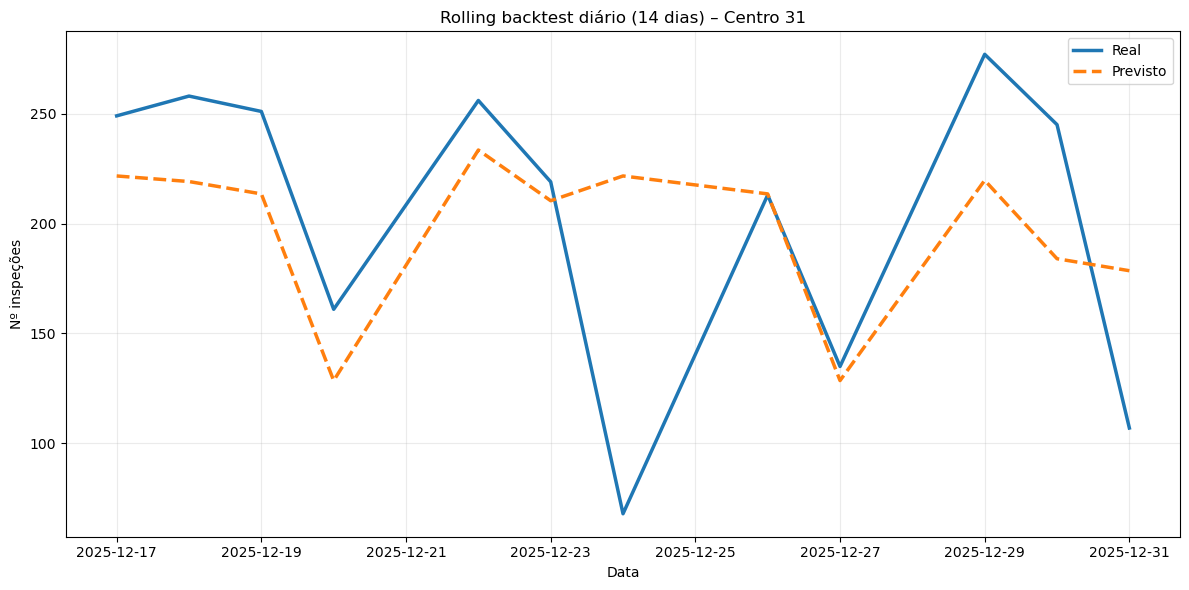

In [46]:
import matplotlib.pyplot as plt

# últimos 14 dias do backtest
cutoff = df_31["DATE"].max() - pd.DateOffset(days=14)
df_plot = df_31[df_31["DATE"] >= cutoff].copy()

plt.figure(figsize=(12,6))

plt.plot(df_plot["DATE"], df_plot["real"], linewidth=2.5, label="Real")
plt.plot(df_plot["DATE"], df_plot["previsto"], linestyle="--", linewidth=2.5, label="Previsto")

plt.title("Rolling backtest diário (14 dias) – Centro 31")
plt.xlabel("Data")
plt.ylabel("Nº inspeções")
plt.grid(True, alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

# exportar para PPT
# plt.savefig("grafico_diario_centro31_14dias.png", dpi=300, bbox_inches="tight")

Features finais usadas no modelo por centro: ['CFGCENTROID', 'dow', 'is_saturday', 'week', 'month', 'year', 'is_holiday']
OK ✅ metrics_diario.parquet
WAPE_global (3 meses, por centro, com feriados): 12.3 %
count    51.000000
mean      0.126038
std       0.018369
min       0.074286
25%       0.115828
50%       0.125634
75%       0.135904
max       0.161621
Name: wape, dtype: float64
OK ✅ dados_diario.parquet


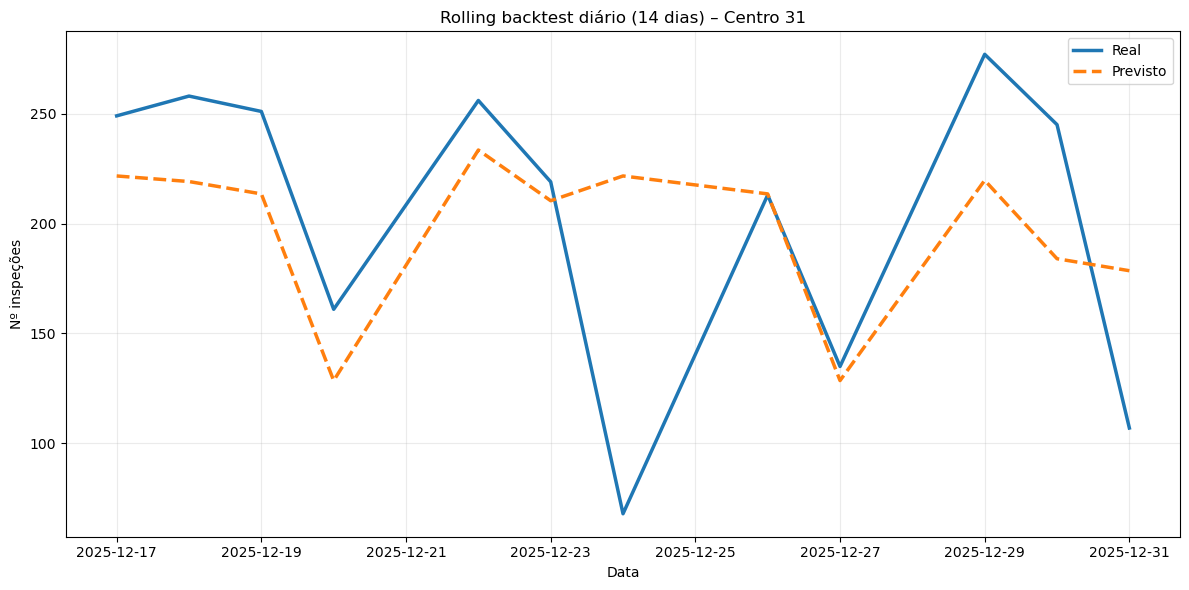

OK ✅ grafico_diario_centro31_14dias.png

--- SLIDE ---
Centro 31 | WAPE: 10.26 % | MAE: 21.98 | RMSE: 31.22
WAPE_global (3 meses): 12.3 %
WAPE mediano centros: 12.56 %


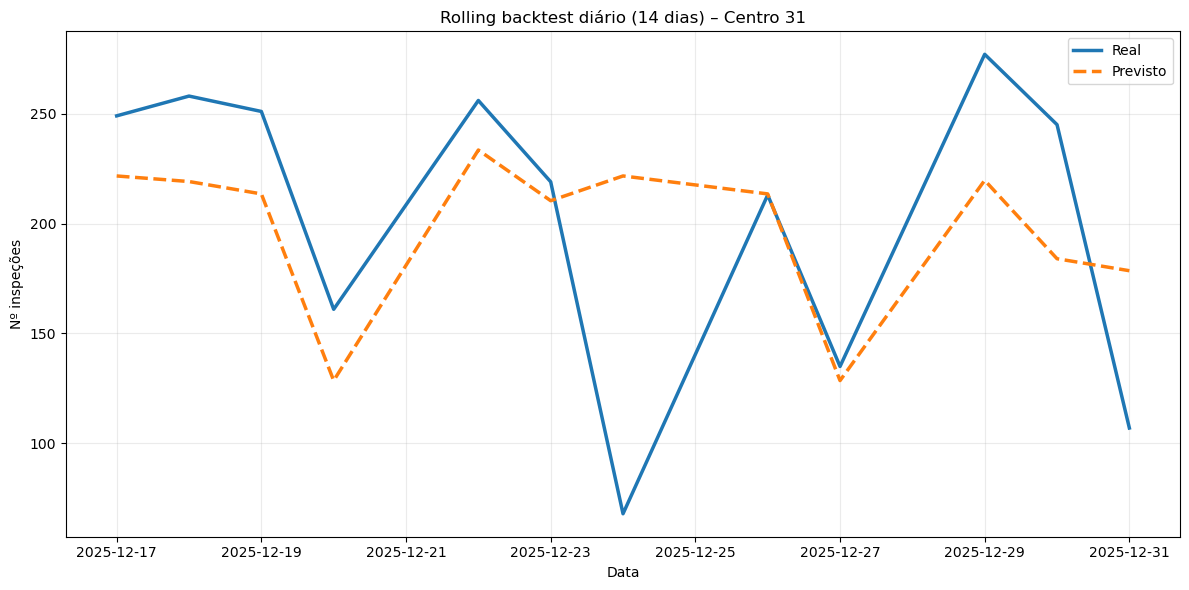

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor

# ============================================================
# 0) Sanity / Inputs esperados
# ============================================================
assert "df_model" in globals(), "Preciso de df_model no notebook."
dfm = df_model.copy()
dfm["data"] = pd.to_datetime(dfm["data"])

# Lista de feriados (no teu notebook já existia)
# Aceita tanto list[str] como list[datetime/date]
if "holidays" not in globals():
    raise ValueError("Não encontrei a variável 'holidays' no notebook. Ela é necessária para is_holiday.")

hol_set = set(pd.to_datetime(list(holidays)).normalize())

# ============================================================
# 1) Criar features temporais + is_holiday (CORREÇÃO)
# ============================================================
dfm["dow"] = dfm["data"].dt.dayofweek
dfm["is_saturday"] = (dfm["dow"] == 5).astype(int)
dfm["week"] = dfm["data"].dt.isocalendar().week.astype(int)
dfm["month"] = dfm["data"].dt.month.astype(int)
dfm["year"] = dfm["data"].dt.year.astype(int)

# NOVO: feriados
dfm["is_holiday"] = dfm["data"].dt.normalize().isin(hol_set).astype(int)

# Features base (iguais às que tens, mas agora com feriados)
features_center = ["CFGCENTROID", "dow", "is_saturday", "week", "month", "year", "is_holiday"]

# Se o teu df_model tiver lags/rolls, também usamos (mantém compatibilidade)
optional = ["lag_1", "lag_7", "lag_14", "lag_28", "roll7_mean", "roll28_mean"]
features_center += [c for c in optional if c in dfm.columns]

print("Features finais usadas no modelo por centro:", features_center)

# ============================================================
# 2) Split igual ao teu modelo por centro (últimos 3 meses)
# ============================================================
test_end = dfm["data"].max()
test_start = test_end - pd.DateOffset(months=3)

train_all = dfm[dfm["data"] <= test_start].copy()
test_all  = dfm[dfm["data"] > test_start].copy()

# ============================================================
# 3) Treinar POR CENTRO + calcular métricas + guardar previsões diárias (para gráfico)
# ============================================================
rows_metrics = []
pred_rows = []

centers = dfm["CFGCENTROID"].unique()

for center in centers:
    train_c = train_all[train_all["CFGCENTROID"] == center].copy()
    test_c  = test_all[test_all["CFGCENTROID"] == center].copy()

    # regra similar à tua (evita centros muito curtos)
    if len(test_c) == 0 or len(train_c) < 200:
        continue

    X_train = train_c[features_center]
    y_train = train_c["y_inspecoes"].astype(float)

    X_test = test_c[features_center]
    y_test = test_c["y_inspecoes"].astype(float)

    model = HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.05,
        max_iter=400,
        random_state=42
    )
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    pred = np.clip(pred, 0, None)

    # CORREÇÃO: feriados a zero (consistente com o teu notebook)
    pred[test_c["is_holiday"].values == 1] = 0.0

    abs_err = np.abs(y_test.values - pred)
    sq_err  = (y_test.values - pred) ** 2

    real_total = float(np.sum(y_test))
    prev_total = float(np.sum(pred))
    mae = float(np.mean(abs_err))
    rmse = float(np.sqrt(np.mean(sq_err)))
    wape = float(np.sum(abs_err) / real_total) if real_total > 0 else np.nan

    rows_metrics.append({
        "CFGCENTROID": int(center),
        "real": real_total,
        "previsto": prev_total,
        "mae": mae,
        "rmse": rmse,
        "wape": wape,
        "n_obs": int(len(test_c)),
        "test_start": test_c["data"].min(),
        "test_end": test_c["data"].max(),
    })

    pred_rows.append(pd.DataFrame({
        "CFGCENTROID": int(center),
        "DATE": pd.to_datetime(test_c["data"]).values,
        "real": y_test.values,
        "previsto": pred
    }))

metrics_diario = pd.DataFrame(rows_metrics).sort_values("CFGCENTROID").reset_index(drop=True)

# WAPE global ponderado (bom para KPI)
WAPE_global = (metrics_diario["real"] * metrics_diario["wape"]).sum() / metrics_diario["real"].sum()
metrics_diario["WAPE_global"] = WAPE_global

# Guardar métricas
metrics_diario.to_parquet("metrics_diario.parquet", index=False)
print("OK ✅ metrics_diario.parquet")
print("WAPE_global (3 meses, por centro, com feriados):", round(WAPE_global*100,2), "%")
print(metrics_diario["wape"].describe())

# ============================================================
# 4) dados_diario.parquet: history 2 semanas + forecast 2 semanas (com feriados)
# ============================================================
# HISTORY: últimos 14 dias reais
hist_end = dfm["data"].max()
hist_start = hist_end - pd.DateOffset(weeks=2)

history_long = (
    dfm[dfm["data"] >= hist_start][["CFGCENTROID", "data", "y_inspecoes"]]
    .rename(columns={"data":"DATE", "y_inspecoes":"value"})
    .copy()
)
history_long["kind"] = "history"

# FORECAST: próximos 14 dias (sem domingos)
future_days = pd.date_range(hist_end + pd.Timedelta(days=1), hist_end + pd.Timedelta(days=14), freq="D")
future_days = future_days[future_days.dayofweek <= 5]

# Para forecast, treinamos um modelo final por centro em TODO o histórico (com feriados)
forecast_rows = []

# utilitários se houver lags/rolls (opcional)
def get_lag(seq, k):
    return seq[-k] if len(seq) >= k else np.nan

def get_roll(seq, k):
    return float(np.mean(seq[-k:])) if len(seq) >= k else np.nan

for center in centers:
    df_c = dfm[dfm["CFGCENTROID"] == center].sort_values("data").copy()
    if len(df_c) < 200:
        continue

    X_train = df_c[features_center]
    y_train = df_c["y_inspecoes"].astype(float)

    model_fcst = HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.05,
        max_iter=400,
        random_state=42
    )
    model_fcst.fit(X_train, y_train)

    # seq para lags/rolls (se usados)
    seq = list(y_train.values)

    for d in future_days:
        feat = {
            "CFGCENTROID": center,
            "dow": d.dayofweek,
            "is_saturday": 1 if d.dayofweek == 5 else 0,
            "week": int(d.isocalendar().week),
            "month": int(d.month),
            "year": int(d.year),
            "is_holiday": 1 if d.normalize() in hol_set else 0
        }

        # lags/rolls se existirem no dfm
        if "lag_1" in dfm.columns: feat["lag_1"] = get_lag(seq, 1)
        if "lag_7" in dfm.columns: feat["lag_7"] = get_lag(seq, 7)
        if "lag_14" in dfm.columns: feat["lag_14"] = get_lag(seq, 14)
        if "lag_28" in dfm.columns: feat["lag_28"] = get_lag(seq, 28)
        if "roll7_mean" in dfm.columns: feat["roll7_mean"] = get_roll(seq, 7)
        if "roll28_mean" in dfm.columns: feat["roll28_mean"] = get_roll(seq, 28)

        X = pd.DataFrame([feat])[features_center]

        yhat = float(model_fcst.predict(X)[0])
        yhat = max(0.0, yhat)

        # feriados a zero
        if feat["is_holiday"] == 1:
            yhat = 0.0

        forecast_rows.append((int(center), d, yhat))
        seq.append(yhat)

forecast_long = pd.DataFrame(forecast_rows, columns=["CFGCENTROID", "DATE", "value"])
forecast_long["kind"] = "forecast"

dados_diario = (
    pd.concat([history_long[["CFGCENTROID","DATE","value","kind"]], forecast_long], ignore_index=True)
    .sort_values(["CFGCENTROID","DATE","kind"])
)

dados_diario.to_parquet("dados_diario.parquet", index=False)
print("OK ✅ dados_diario.parquet")

# ============================================================
# 5) Gráfico para o slide: Rolling backtest 14 dias – Centro 31
# ============================================================
df_backtest_daily = pd.concat(pred_rows, ignore_index=True)
df_backtest_daily["DATE"] = pd.to_datetime(df_backtest_daily["DATE"])

CENTER = 31
df_31 = df_backtest_daily[df_backtest_daily["CFGCENTROID"] == CENTER].sort_values("DATE").copy()

cutoff = df_31["DATE"].max() - pd.DateOffset(days=14)
df_plot = df_31[df_31["DATE"] >= cutoff].copy()

plt.figure(figsize=(12,6))
plt.plot(df_plot["DATE"], df_plot["real"], linewidth=2.5, label="Real")
plt.plot(df_plot["DATE"], df_plot["previsto"], linestyle="--", linewidth=2.5, label="Previsto")

plt.title("Rolling backtest diário (14 dias) – Centro 31")
plt.xlabel("Data")
plt.ylabel("Nº inspeções")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# Guardar PNG para usar no PowerPoint
plt.figure(figsize=(12,6))
plt.plot(df_plot["DATE"], df_plot["real"], linewidth=2.5, label="Real")
plt.plot(df_plot["DATE"], df_plot["previsto"], linestyle="--", linewidth=2.5, label="Previsto")
plt.title("Rolling backtest diário (14 dias) – Centro 31")
plt.xlabel("Data")
plt.ylabel("Nº inspeções")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("grafico_diario_centro31_14dias.png", dpi=300, bbox_inches="tight")
print("OK ✅ grafico_diario_centro31_14dias.png")

# ============================================================
# 6) Números prontos para o slide (Centro 31 + KPI global)
# ============================================================
m31 = metrics_diario[metrics_diario["CFGCENTROID"] == 31].iloc[0]
print("\n--- SLIDE ---")
print("Centro 31 | WAPE:", round(m31["wape"]*100,2), "% | MAE:", round(m31["mae"],2), "| RMSE:", round(m31["rmse"],2))
print("WAPE_global (3 meses):", round(WAPE_global*100,2), "%")
print("WAPE mediano centros:", round(metrics_diario['wape'].median()*100,2), "%")

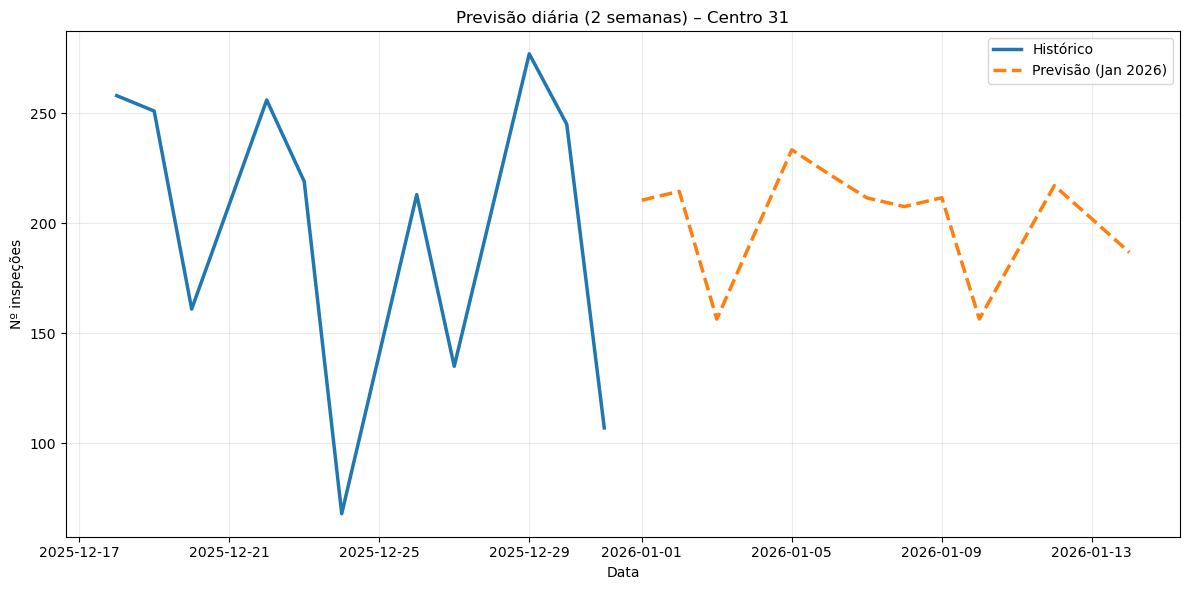

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor

# =========================
# Config
# =========================
CENTER = 31
HIST_DAYS = 14

FORECAST_START = pd.Timestamp("2026-01-01")
FORECAST_END   = pd.Timestamp("2026-01-14")  # 2 semanas (14 dias)

EXCLUDE_SUNDAYS = True  # mete False se quiseres incluir domingos

# =========================
# Sanity
# =========================
assert "df_model" in globals(), "Preciso de df_model no notebook."
assert "holidays" in globals(), "Preciso da lista 'holidays' no notebook (feriados)."

dfm = df_model.copy()
dfm["data"] = pd.to_datetime(dfm["data"])

# Feriados
hol_set = set(pd.to_datetime(list(holidays)).normalize())

# =========================
# Construir features (inclui feriados)
# =========================
dfm["dow"] = dfm["data"].dt.dayofweek
dfm["is_saturday"] = (dfm["dow"] == 5).astype(int)
dfm["week"] = dfm["data"].dt.isocalendar().week.astype(int)
dfm["month"] = dfm["data"].dt.month.astype(int)
dfm["year"] = dfm["data"].dt.year.astype(int)
dfm["is_holiday"] = dfm["data"].dt.normalize().isin(hol_set).astype(int)

# Features usadas no modelo (compatível com o teu notebook)
features = ["CFGCENTROID", "dow", "is_saturday", "week", "month", "year", "is_holiday"]

# (Opcional) Se tiveres lags/rolls no df_model, usa também
optional = ["lag_1", "lag_7", "lag_14", "lag_28", "roll7_mean", "roll28_mean"]
features += [c for c in optional if c in dfm.columns]

# =========================
# 1) HISTÓRICO: últimas 2 semanas ANTES de 2026-01-01
# =========================
hist_start = FORECAST_START - pd.Timedelta(days=HIST_DAYS)
hist_end = FORECAST_START - pd.Timedelta(days=1)

hist = dfm[
    (dfm["CFGCENTROID"] == CENTER) &
    (dfm["data"] >= hist_start) &
    (dfm["data"] <= hist_end)
][["data", "y_inspecoes"]].copy()

hist = hist.rename(columns={"data": "DATE", "y_inspecoes": "value"})
hist["kind"] = "history"

# =========================
# 2) Treinar modelo POR CENTRO (com feriados)
#     Treinamos com histórico até 2025-12-31
# =========================
train_cutoff = pd.Timestamp("2025-12-31")

train_c = dfm[(dfm["CFGCENTROID"] == CENTER) & (dfm["data"] <= train_cutoff)].copy()
if len(train_c) < 200:
    raise ValueError(f"Centro {CENTER} tem poucos dados para treinar ({len(train_c)} linhas).")

X_train = train_c[features]
y_train = train_c["y_inspecoes"].astype(float)

model = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=400,
    random_state=42
)
model.fit(X_train, y_train)

# =========================
# 3) FORECAST: 2026-01-01 a 2026-01-14
# =========================
future_days = pd.date_range(FORECAST_START, FORECAST_END, freq="D")
if EXCLUDE_SUNDAYS:
    future_days = future_days[future_days.dayofweek <= 5]

# Se fores usar lags/rolls, precisas de recursão com a série:
seq = list(train_c.sort_values("data")["y_inspecoes"].astype(float).values)

def get_lag(seq, k):
    return seq[-k] if len(seq) >= k else np.nan

def get_roll(seq, k):
    return float(np.mean(seq[-k:])) if len(seq) >= k else np.nan

rows = []
for d in future_days:
    feat = {
        "CFGCENTROID": CENTER,
        "dow": d.dayofweek,
        "is_saturday": 1 if d.dayofweek == 5 else 0,
        "week": int(d.isocalendar().week),
        "month": int(d.month),
        "year": int(d.year),
        "is_holiday": 1 if d.normalize() in hol_set else 0,
    }

    # lags/rolls se existirem
    if "lag_1" in features: feat["lag_1"] = get_lag(seq, 1)
    if "lag_7" in features: feat["lag_7"] = get_lag(seq, 7)
    if "lag_14" in features: feat["lag_14"] = get_lag(seq, 14)
    if "lag_28" in features: feat["lag_28"] = get_lag(seq, 28)
    if "roll7_mean" in features: feat["roll7_mean"] = get_roll(seq, 7)
    if "roll28_mean" in features: feat["roll28_mean"] = get_roll(seq, 28)

    X = pd.DataFrame([feat])[features]
    yhat = float(model.predict(X)[0])
    yhat = max(0.0, yhat)

    # regra feriado: previsão a 0
    if feat["is_holiday"] == 1:
        yhat = 0.0

    rows.append((d, yhat))
    seq.append(yhat)

fcst = pd.DataFrame(rows, columns=["DATE", "value"])
fcst["kind"] = "forecast"

# =========================
# 4) Plot (igual ao estilo dos outros slides)
# =========================
df_plot = pd.concat([hist, fcst], ignore_index=True).sort_values("DATE")

plt.figure(figsize=(12,6))

plt.plot(
    df_plot[df_plot["kind"]=="history"]["DATE"],
    df_plot[df_plot["kind"]=="history"]["value"],
    linewidth=2.5,
    label="Histórico"
)

plt.plot(
    df_plot[df_plot["kind"]=="forecast"]["DATE"],
    df_plot[df_plot["kind"]=="forecast"]["value"],
    linewidth=2.5,
    linestyle="--",
    label="Previsão (Jan 2026)"
)

plt.title("Previsão diária (2 semanas) – Centro 31")
plt.xlabel("Data")
plt.ylabel("Nº inspeções")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# opcional: exportar PNG para PPT
# plt.savefig("previsao_diaria_centro31_jan2026.png", dpi=300, bbox_inches="tight")

In [52]:
df_model["data"] = pd.to_datetime(df_model["data"])

hol_set = set(pd.to_datetime(list(holidays)).normalize())

df_model["is_holiday"] = (
    df_model["data"].dt.normalize().isin(hol_set)
).astype(int)

df_model[df_model["data"].isin(["2025-12-24","2025-12-25"])][
    ["data","y_inspecoes","is_holiday","CFGCENTROID"]
].query("CFGCENTROID==31")

/tmp/ipykernel_1751/2264150827.py:9: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df_model[df_model["data"].isin(["2025-12-24","2025-12-25"])][


,data,y_inspecoes,is_holiday,CFGCENTROID
20523,2025-12-24,68,0,31
